**KNN model using Iris Dataset**

In [52]:
from sklearn.datasets import load_iris
import pandas as pd

iris = load_iris()
df = pd.DataFrame(data = iris.data, columns=iris.feature_names)
df['species'] = iris.target
print(df.head(150))
print(df.info())
print(df.describe())

     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                  5.1               3.5                1.4               0.2   
1                  4.9               3.0                1.4               0.2   
2                  4.7               3.2                1.3               0.2   
3                  4.6               3.1                1.5               0.2   
4                  5.0               3.6                1.4               0.2   
..                 ...               ...                ...               ...   
145                6.7               3.0                5.2               2.3   
146                6.3               2.5                5.0               1.9   
147                6.5               3.0                5.2               2.0   
148                6.2               3.4                5.4               2.3   
149                5.9               3.0                5.1               1.8   

     species  
0          0

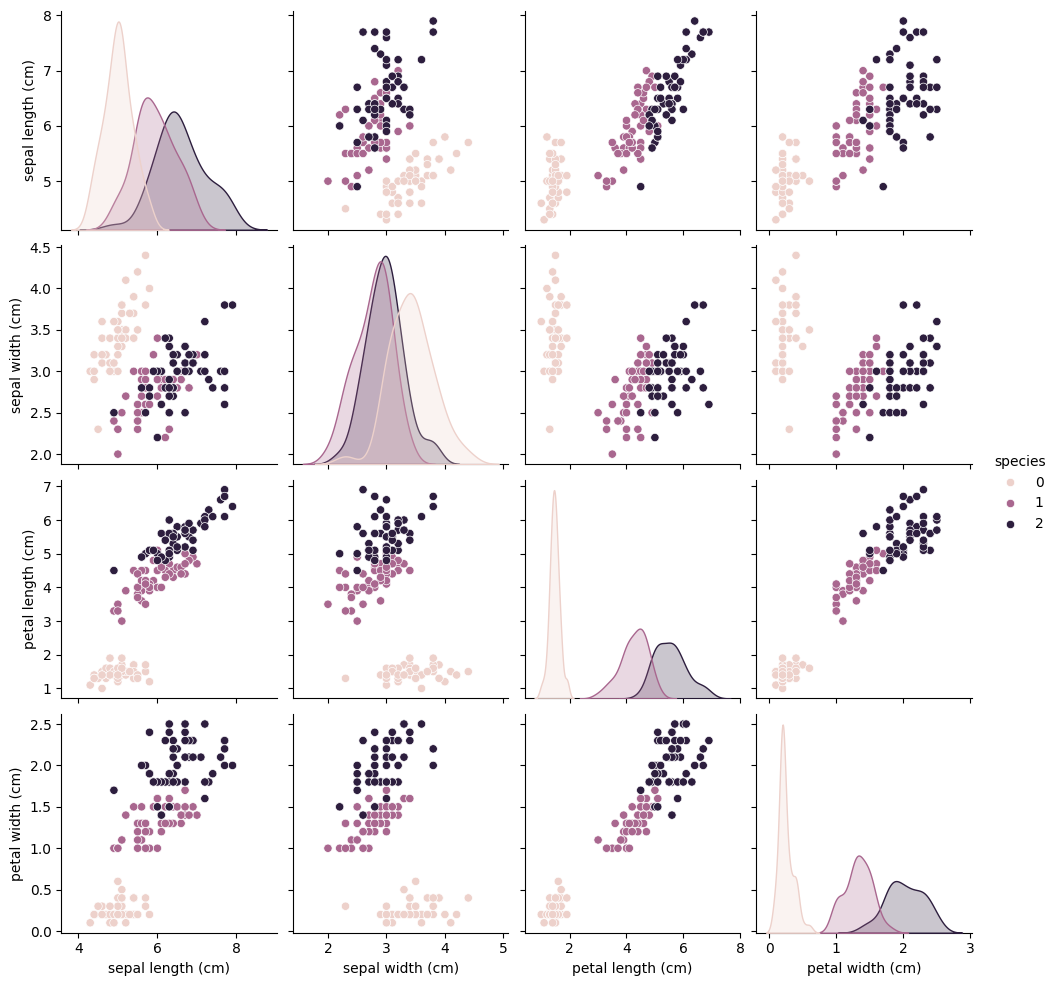

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(df, hue='species')
plt.show()

In [54]:
from sklearn.preprocessing import StandardScaler
# X = just the 4 numerical feature columns
X = df[['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']]

# y = the target species column (the answer key)
y = df['species']

# 1. Initialize the tool
scaler = StandardScaler()

# 2. Calculate patterns AND transform the data in one shot
X_scaled = scaler.fit_transform(X)

print(X_scaled[0:10])

[[-0.90068117  1.01900435 -1.34022653 -1.3154443 ]
 [-1.14301691 -0.13197948 -1.34022653 -1.3154443 ]
 [-1.38535265  0.32841405 -1.39706395 -1.3154443 ]
 [-1.50652052  0.09821729 -1.2833891  -1.3154443 ]
 [-1.02184904  1.24920112 -1.34022653 -1.3154443 ]
 [-0.53717756  1.93979142 -1.16971425 -1.05217993]
 [-1.50652052  0.78880759 -1.34022653 -1.18381211]
 [-1.02184904  0.78880759 -1.2833891  -1.3154443 ]
 [-1.74885626 -0.36217625 -1.34022653 -1.3154443 ]
 [-1.14301691  0.09821729 -1.2833891  -1.44707648]]


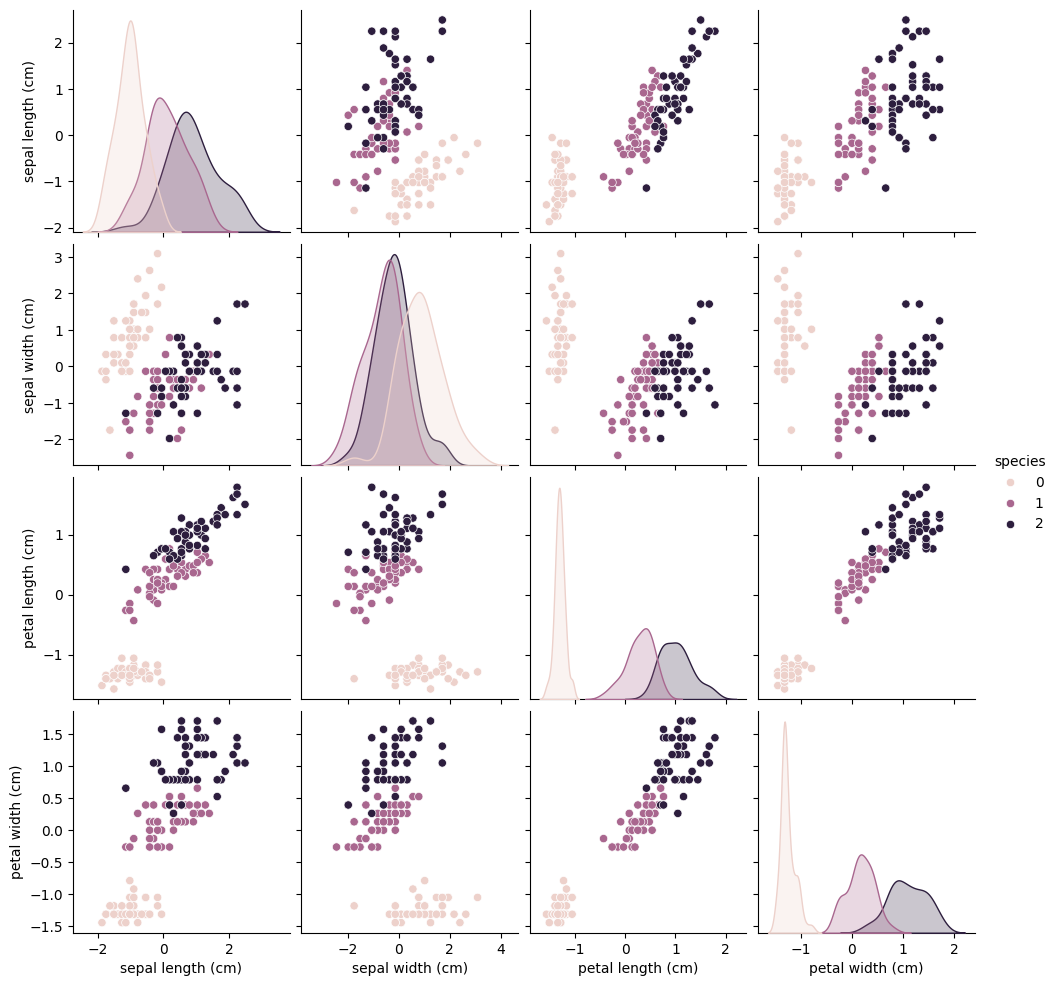

In [55]:
df_normalized = pd.DataFrame(data=X_scaled,columns=iris.feature_names)
df_normalized['species'] = y

sns.pairplot(df_normalized, hue='species')
plt.show()


In [56]:
df_normalized

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,-0.900681,1.019004,-1.340227,-1.315444,0
1,-1.143017,-0.131979,-1.340227,-1.315444,0
2,-1.385353,0.328414,-1.397064,-1.315444,0
3,-1.506521,0.098217,-1.283389,-1.315444,0
4,-1.021849,1.249201,-1.340227,-1.315444,0
...,...,...,...,...,...
145,1.038005,-0.131979,0.819596,1.448832,2
146,0.553333,-1.282963,0.705921,0.922303,2
147,0.795669,-0.131979,0.819596,1.053935,2
148,0.432165,0.788808,0.933271,1.448832,2


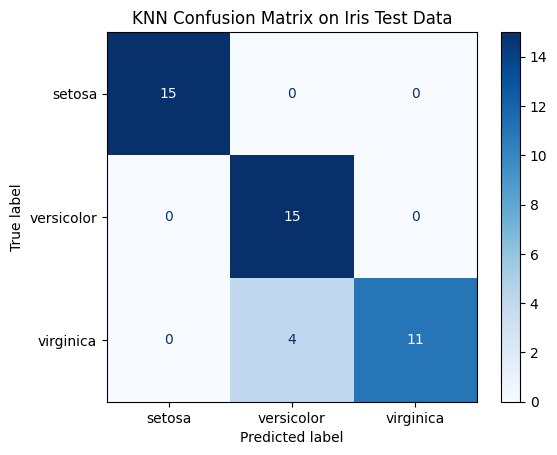

In [57]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

X_train,X_test,y_train,y_test = train_test_split(X_scaled, y, test_size = 0.3, random_state = 42, stratify = y)

model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train,y_train)
predict_X = model.predict(X_test) # y_test contain actual results of the predict_X

# Generate and plot the confusion matrix
ConfusionMatrixDisplay.from_estimator(
    model,
    X_test,
    y_test,
    display_labels=iris.target_names, # Shows actual species names instead of 0, 1, 2
    cmap=plt.cm.Blues
)

plt.title("KNN Confusion Matrix on Iris Test Data")
plt.show()

In [58]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# accuracy
accuracy = accuracy_score(y_test, predict_X)
print('Accuracy: ', accuracy)

# precision
precision = precision_score(y_test, predict_X, average='macro') #  average='macro' used for the multiclass dataset like Iris dataset
print('Precision: ', precision)

# recall
recall = recall_score(y_test, predict_X, average='macro')
print('Recall: ', recall)

# F1_Score
f1 = f1_score(y_test, predict_X, average='macro')
print('F1 Score: ', f1)

Accuracy:  0.9111111111111111
Precision:  0.9298245614035089
Recall:  0.9111111111111111
F1 Score:  0.9095022624434389


**Now Testing the model with different datasets**

In [64]:
confusing_data = pd.DataFrame([
    [6.0, 3.0, 4.8, 1.8],
    [6.7, 3.0, 5.0, 1.7],
    [4.9, 2.5, 4.5, 1.7],
    [6.0, 2.7, 5.1, 1.6],
    [5.9, 3.2, 4.8, 1.8],
    [5.0, 2.3, 3.3, 1.0]
], columns=iris.feature_names)

true_labels = [2, 1, 2, 1, 2, 1]
scaled_data = scaler.transform(confusing_data)

df = pd.DataFrame(scaled_data,columns=confusing_data.columns)
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,0.189830,-0.131979,0.592246,0.790671
1,1.038005,-0.131979,0.705921,0.659038
2,-1.143017,-1.282963,0.421734,0.659038
3,0.189830,-0.822570,0.762758,0.527406
4,0.068662,0.328414,0.592246,0.790671
5,-1.021849,-1.743357,-0.260315,-0.262387


In [74]:
predicted = model.predict(scaled_data)
print(predicted)

[1 1 1 2 1 1]


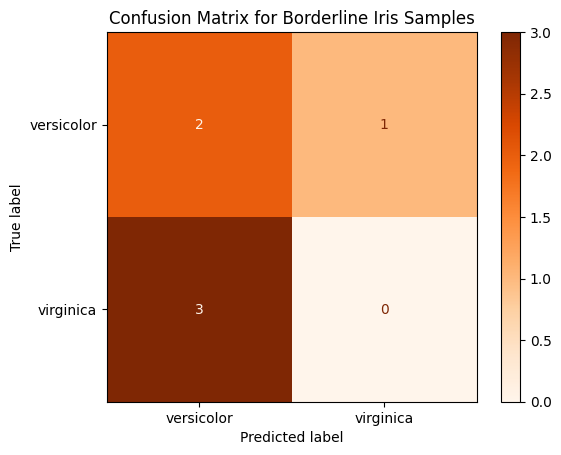

In [76]:
display_names = ['versicolor', 'virginica']

# Generate and plot the matrix from your predictions
ConfusionMatrixDisplay.from_predictions(
    true_labels,
    predicted,
    display_labels=display_names,
    cmap=plt.cm.Oranges  # A warm color scheme to highlight any mistakes
)

plt.title("Confusion Matrix for Borderline Iris Samples")
plt.show()

2 represents versicolor and 1 represents virginica in the true labels. Hence there are 3 versicolor and 2 virginica

In the above confusion matrix it shows that model predicted 2 versicolor correctly but it predicted virginica specy wrongly